# 🎓 Postdoctoral Market Simulation — Interactive Companion

## Stochasticity, Noise, and Your Chances

This notebook is an **interactive companion** to the blog post on postdoctoral job market simulation. If you haven't read it yet, I recommend starting there for context on the model, assumptions, and what these numbers mean.

### What is this?

We model a simplified postdoctoral job market with:
- **~850 applicants** (~750 students + ~100 postdocs reapplying) drawn from a total cohort of 1000 graduates and 300 postdocs
- **256 open positions** across 3 prestige tiers: 6 Society of Fellows, 50 Fellowships, 200 standard postdocs
- **Rank noise** via the [Mallows model](https://en.wikipedia.org/wiki/Mallows_distribution): each hiring committee adds independent stochastic perturbations to the true skill-ordered ranking, calibrated to $\phi = 0.74$ (matching empirical committee variability)
- **Strategic behavior**: applicants choose how many positions to pursue; institutions make offers in successive rounds

### Why does this matter?

The postdoc market is **stochastic**—your ranking on one committee's list may differ significantly from another's. This notebook helps you:
1. Run a single market diagnostic to see what can happen
2. Estimate your personal success rates across different self-assessments and application strategies
3. Make data-informed decisions about how many positions to target

**Disclaimer:** This model is simplified; real markets involve subfields, geographic preferences, and many other factors. Use this as a thinking tool, not gospel.

## Cell 2: Setup

Clone the GitHub repository, install dependencies, and import the simulation module.

In [11]:
# Install dependencies quietly
!pip install scipy -q 2>/dev/null

# Clone the repository
import os
if not os.path.exists('repo'):
    !git clone https://github.com/astrockragh/postdoc_market_simulation.git repo 2>&1 | tail -1
    !git clone https://github.com/ekhiru/top-k-mallows.git repo/top-k-mallows 2>&1 | tail -1
    print("✓ Repository cloned.")
else:
    !rm -r repo
    !git clone https://github.com/astrockragh/postdoc_market_simulation.git repo 2>&1 | tail -1
    !git clone https://github.com/ekhiru/top-k-mallows.git repo/top-k-mallows 2>&1 | tail -1

    print("✓ Repository reloaded and recloned.")

# Set up paths
import sys
sys.path.insert(0, '/content/repo')
sys.path.insert(0, '/content/repo/top-k-mallows')

# Import everything we need
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import warnings
warnings.filterwarnings('ignore')

# Import the simulation module
from postdoc_market import (
    ApplicantCohort,
    run_injected_multi,
    run_grid_sweep_per_n_apps,
    print_tables
)

# Set matplotlib to inline rendering
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print("✓ All imports successful. Ready to simulate!")

Cloning into 'repo'...
Cloning into 'repo/top-k-mallows'...
✓ Repository reloaded and recloned.
✓ All imports successful. Ready to simulate!


## Cell 3: Configure Your Market

Before we run simulations, let's understand what we're asking:

### **What is your percentile?**
Discuss with your mentor. "Top 10%" means you're in the best 10% of students in your cohort. This is about **your research skill**, not your friendliness or luck. Remember, out of ~1000 graduates only ~750 actually apply, so your percentile is relative to those ~750:
- Top 5% → rank ~38 among ~750 applying students
- Top 10% → rank ~75
- Top 20% → rank ~150
- Top 50% → rank ~375

### **How many applications?**
Each application means one pool you're ranked in. The committee applies its Mallows noise independently to each pool, so more applications → more independent chances. But there are diminishing returns.
- 5 applications: fast, low-cost
- 20–30 applications: reasonable coverage
- 60–80 applications: comprehensive, but effort scales linearly

### **How many simulation runs?**
Each run is one random market realization and takes ~5 seconds. More runs = more accurate statistics, but slower.
- 50 runs: quick preview (~5 min)
- 200 runs: solid statistics (~20 min)
- 500 runs: Beat the noise down (~1 hr)

## Cell 4: Your Parameters

Edit the values below.

In [23]:
# === YOUR PARAMETERS ===
# Work with your mentor to estimate your ranking.
# Remember: this is about research skill, not publications or luck.

# Your optimistic percentile (best-case scenario)
MY_PERCENTILE_LOW = 5

# Your pessimistic percentile (worst reasonable scenario)
MY_PERCENTILE_HIGH = 20

# Minimum number of applications you're willing to send
MIN_APPLICATIONS = 10

# Maximum number of applications you're willing to send
MAX_APPLICATIONS = 50

# Number of simulation runs
N_RUNS = 50

# Maximum number of offer rounds in each market
OFFER_ROUNDS = 10

print("\n" + "="*60)
print("YOUR SCENARIO")
print("="*60)
print(f"Percentile range:       {MY_PERCENTILE_LOW}% to {MY_PERCENTILE_HIGH}% (best to worst)")
print(f"Application range:      {MIN_APPLICATIONS} to {MAX_APPLICATIONS}")
print(f"Simulation runs:        {N_RUNS}")
print(f"Offer rounds per run:   {OFFER_ROUNDS}")
print("="*60 + "\n")


YOUR SCENARIO
Percentile range:       5% to 15% (best to worst)
Application range:      10 to 50
Simulation runs:        50
Offer rounds per run:   10



## Step 1: Single Market Diagnostic

Let's run **one example market** with you (at the midpoint of your percentile estimate) applying to the average number of positions. This shows:
- Whether you receive any offers
- If so, in which round(s)
- What prestige level you land in (if you accept)
- How your rank compares to the committee rankings


In [24]:
print("\n" + "#"*60)
print("# SINGLE MARKET DIAGNOSTIC")
print("#"*60 + "\n")

# Calculate midpoint parameters
mid_pct = (MY_PERCENTILE_LOW + MY_PERCENTILE_HIGH) / 2
mid_apps = (MIN_APPLICATIONS + MAX_APPLICATIONS) // 2

print(f"Injecting candidate at {mid_pct:.1f}% percentile")
print(f"with {mid_apps} applications.\n")

# Create and run one market
cohort = ApplicantCohort(
    n_students=1000,
    n_postdocs=300,
    splits=np.array([6, 50, 200]),
    stochasticity=0.74,
    verbose=1
)

cohort.rank_applicants()
cohort.inject_candidate(student_percentile=mid_pct, n_applications=mid_apps)
cohort.run_market(offer_rounds=OFFER_ROUNDS)

result = cohort.get_injected_result()

print("\n" + "="*60)
print("OUTCOME FOR YOUR INJECTED CANDIDATE")
print("="*60)
print(f"Got at least one offer?    {result['got_offer']}")
print(f"Total offers received:     {result['n_offers']}")
print(f"Accepted an offer?         {result['accepted']}")
if result['accepted']:
    print(f"Round of acceptance:       {result['accepted_round']}")
    print(f"Prestige of accepted job:  {result['accepted_prestige']:.3f}")
else:
    print(f"(No acceptance in this run)")
print("="*60 + "\n")

# Store cohort for visualization
diagnostic_cohort = cohort
diagnostic_result = result


############################################################
# SINGLE MARKET DIAGNOSTIC
############################################################

Injecting candidate at 10.0% percentile
with 30 applications.


[rank_applicants]  850 applicants  (750 students, 100 postdocs)
  skill range: [-3.623, 3.104]

[inject_candidate]
  student_percentile : 10.0%
  target_skill       : 1.2678
  overall position   : 125 / 851  (14.7% overall)
  student rank       : 75 / 751
  n_applications     : 30  (fixed)

  MARKET OPEN

[assign_application_counts]
  students: n=751, mean_apps=32.34, max=116
  postdocs: n=100, mean_apps=16.58, max=48

[build_prestige]  256 positions
  prestige range: [0.694, 6.545]
  tier 0: 6 positions, prestige [3.71, 6.18]
  tier 1: 50 positions, prestige [1.86, 6.55]
  tier 2: 200 positions, prestige [0.69, 1.45]

[build_application_pools]
  pool sizes: min=41, mean=101.3, max=522, empty=0

────────────────────────────────────────────────────────────
  ROUND 1  |  open=

## Visualization: Your Position in the Market

The scatter plot below shows the match between true applicant rank (x-axis) and committee ranking (y-axis). Your injected candidate is marked with a **large red star**.

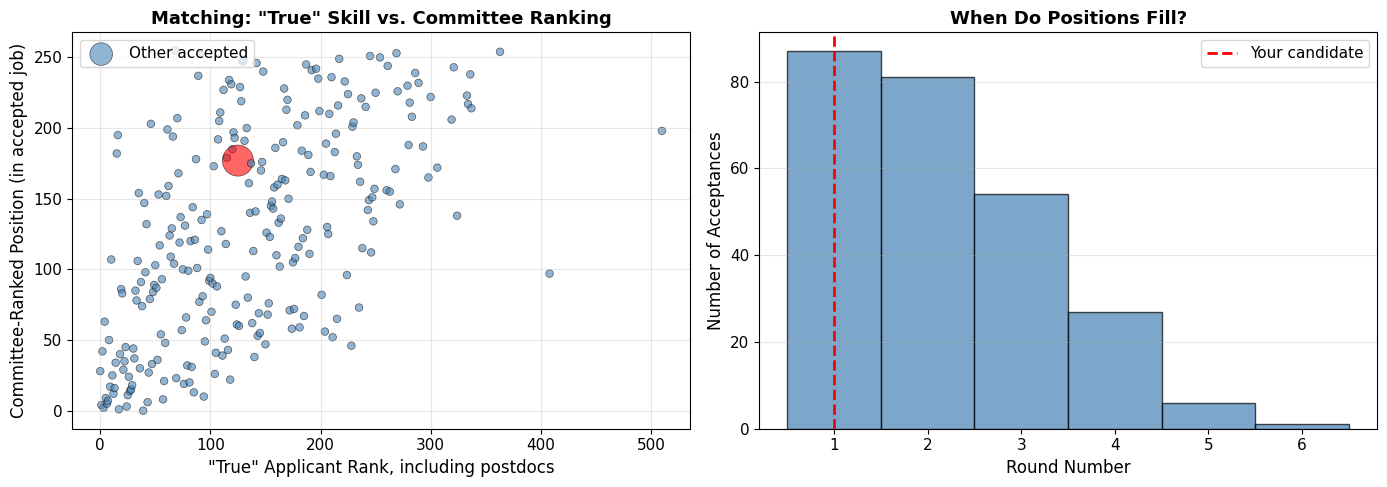

Total acceptances in this market: 256
Your candidate: Accepted ✓


In [25]:
if not diagnostic_result['got_offer']:
    print("\n" + "!"*60)
    print("!!" + " "*14 + "NO OFFERS RECEIVED" + " "*14 + "!!")
    print("!" + " "*58 + "!")
    print("!!" + "  Your candidate did not get any offers " + " "*7 + "!!")
    print("!!" + "  in this market realization." + " "*18 + "!!")
    print("!!" + " "*56 + "!!")
    print("!!" + "  This is normal — it's a stochastic process!" + " "*3 + "!!")
    print("!!" + "  Re-run the cells above to try another market." + " " + "!!")
    print("!" + " "*58 + "!")
    print("!"*60 + "\n")
else:
  # Create a job rank mapping
  job_rank = {j['id']: rank for rank, j in enumerate(sorted(diagnostic_cohort.jobs, key=lambda x: -x['prestige']))}

  # Build data for scatter plot
  true_ranks = []
  committee_ranks = []
  colors = []
  sizes = []

  injected_idx = diagnostic_cohort._injected_idx

  for app in diagnostic_cohort.applicants:
      if app['accepted']:
          job_id = app['accepted_job']
          committee_rank = job_rank.get(job_id, -1)

          true_ranks.append(app['rank'])
          committee_ranks.append(committee_rank)

          if app['injected']:
              colors.append('red')
              sizes.append(500)
          else:
              colors.append('steelblue')
              sizes.append(30)

  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

  # Left: Applicant rank vs committee rank
  if true_ranks:
      ax1.scatter(true_ranks, committee_ranks, s=sizes, c=colors, alpha=0.6, edgecolors='black', linewidth=0.5)
      ax1.set_xlabel('"True" Applicant Rank, including postdocs', fontsize=12)
      ax1.set_ylabel('Committee-Ranked Position (in accepted job)', fontsize=12)
      ax1.set_title('Matching: "True" Skill vs. Committee Ranking', fontsize=13, fontweight='bold')
      ax1.grid(alpha=0.3)

      if any(c == 'red' for c in colors):
          ax1.legend(['Other accepted', 'Your candidate'], loc='upper left')

  # Right: Histogram of acceptances by round
  acceptance_rounds = [a['accepted_round'] for a in diagnostic_cohort.applicants if a['accepted']]
  if acceptance_rounds:
      bins = np.arange(1, max(acceptance_rounds) + 2) - 0.5
      ax2.hist(acceptance_rounds, bins=bins, color='steelblue', alpha=0.7, edgecolor='black')
      if diagnostic_result['accepted']:
          ax2.axvline(diagnostic_result['accepted_round'], color='red', linestyle='--', linewidth=2, label='Your candidate')
          ax2.legend()
      ax2.set_xlabel('Round Number', fontsize=12)
      ax2.set_ylabel('Number of Acceptances', fontsize=12)
      ax2.set_title('When Do Positions Fill?', fontsize=13, fontweight='bold')
      ax2.grid(alpha=0.3, axis='y')

  plt.tight_layout()
  plt.show()

  print(f"Total acceptances in this market: {sum(1 for a in diagnostic_cohort.applicants if a['accepted'])}")
  print(f"Your candidate: {'Accepted ✓' if diagnostic_result['accepted'] else 'Did not accept ✗'}")

## Step 2: Personalized Success Rates

Now we run a **grid sweep**: many combinations of percentile and application count across multiple market realizations. This gives us P(offer), P(acceptance), and expected prestige for each scenario.

This will take a ~30 minutes (depending on N_RUNS). Progress bars will show where we are.

In [26]:
print("\n" + "#"*60)
print("# GRID SWEEP: PERCENTILE × APPLICATION COUNT")
print("#"*60 + "\n")

# Define grid
N_PCT_TESTS = 5
N_APP_TESTS = 5
percentiles = np.unique(np.linspace(MY_PERCENTILE_LOW, MY_PERCENTILE_HIGH, N_PCT_TESTS, dtype=int)).tolist()
n_apps_grid = np.unique(np.logspace(np.log10(max(MIN_APPLICATIONS, 2)), np.log10(MAX_APPLICATIONS), N_APP_TESTS).astype(int)).tolist()

print(f"Percentiles: {percentiles}")
print(f"Application counts: {n_apps_grid}")
print(f"Total cells: {len(percentiles)} × {len(n_apps_grid)} = {len(percentiles) * len(n_apps_grid)}")
print(f"Runs per cell: {N_RUNS}")
print(f"Total markets: {len(percentiles) * len(n_apps_grid) * N_RUNS}")
print(f"\nStarting sweep...\n")

# n_students=1000 and n_postdocs=300 are the TOTAL cohort sizes;
# the module internally applies frac_student_applying=3/4 and
# frac_postdoc_applying=1/3, giving ~750 students + ~100 postdocs.
cohort_kwargs = {
    'n_students': 1000,
    'n_postdocs': 300,
    'splits': np.array([6, 50, 200]),
    'stochasticity': 0.74,
}

results = run_grid_sweep_per_n_apps(
    percentiles=percentiles,
    n_apps_grid=n_apps_grid,
    n_runs=N_RUNS,
    offer_rounds=OFFER_ROUNDS,
    cohort_kwargs=cohort_kwargs
)

print(f"\n✓ Sweep complete. {len(results)} cells aggregated.")


############################################################
# GRID SWEEP: PERCENTILE × APPLICATION COUNT
############################################################

Percentiles: [5, 7, 10, 12, 15]
Application counts: [10, 14, 22, 33, 49]
Total cells: 5 × 5 = 25
Runs per cell: 50
Total markets: 1250

Starting sweep...


[per_n_apps batch]  n_apps=10  (50 runs, 5 percentiles each) ...


n_apps=10:   0%|          | 0/50 [00:00<?, ?it/s]


[per_n_apps batch]  n_apps=14  (50 runs, 5 percentiles each) ...


n_apps=14:   0%|          | 0/50 [00:00<?, ?it/s]


[per_n_apps batch]  n_apps=22  (50 runs, 5 percentiles each) ...


...


[per_n_apps batch]  n_apps=33  (50 runs, 5 percentiles each) ...


n_apps=33:   0%|          | 0/50 [00:00<?, ?it/s]


[per_n_apps batch]  n_apps=49  (50 runs, 5 percentiles each) ...


n_apps=49:   0%|          | 0/50 [00:00<?, ?it/s]


✓ Sweep complete. 25 cells aggregated.


## Step 3: Heatmap — P(at least one offer)

The heatmap shows your probability of receiving at least one offer, as a function of percentile (y-axis) and application count (x-axis). Green = high chance, red = low chance.

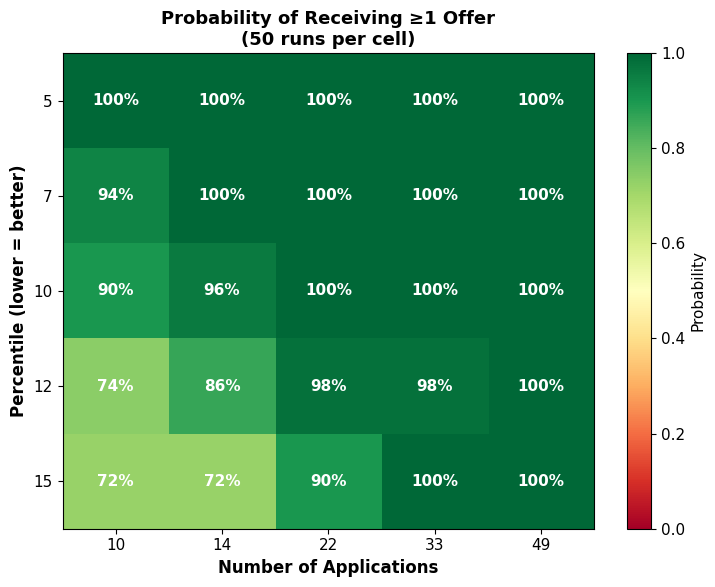


Your range: 5%–15% percentile, 10–50 applications


In [27]:
# Build 2D array of offer rates
offer_grid = np.full((len(percentiles), len(n_apps_grid)), np.nan)

for res in results:
    try:
        i = list(percentiles).index(res['student_percentile'])
        j = list(n_apps_grid).index(res['n_applications'])
        offer_grid[i, j] = res['offer_rate']
    except ValueError:
        pass

# Create heatmap
fig, ax = plt.subplots(figsize=(N_APP_TESTS*1.5, N_PCT_TESTS*1.2))

# Use RdYlGn colormap
im = ax.imshow(offer_grid, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1, origin='upper')

# Set ticks and labels
ax.set_xticks(range(len(n_apps_grid)))
ax.set_yticks(range(len(percentiles)))
ax.set_xticklabels(n_apps_grid)
ax.set_yticklabels(percentiles)

ax.set_xlabel('Number of Applications', fontsize=12, fontweight='bold')
ax.set_ylabel('Percentile (lower = better)', fontsize=12, fontweight='bold')
ax.set_title(f'Probability of Receiving ≥1 Offer\n({N_RUNS} runs per cell)', fontsize=13, fontweight='bold')

# Annotate cells with percentages
for i in range(len(percentiles)):
    for j in range(len(n_apps_grid)):
        val = offer_grid[i, j]
        if not np.isnan(val):
            text = ax.text(j, i, f'{val*100:.0f}%', ha='center', va='center',
                           color='black' if 0.3 < val < 0.7 else 'white', fontweight='bold')

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Probability', fontsize=11)

plt.tight_layout()
plt.show()

print(f"\nYour range: {MY_PERCENTILE_LOW}%–{MY_PERCENTILE_HIGH}% percentile, {MIN_APPLICATIONS}–{MAX_APPLICATIONS} applications")

## Step 4: Summary Tables

Detailed statistics for each cell: offer rate, acceptance rate, mean offers, mean prestige, and mean acceptance round.

In [28]:
# Prepare data for nice table display
print("\n" + "="*100)
print("DETAILED STATISTICS BY PERCENTILE AND APPLICATION COUNT")
print("="*100 + "\n")

from collections import defaultdict

# Group by percentile
by_pct = defaultdict(list)
for res in results:
    by_pct[res['student_percentile']].append(res)

for pct in sorted(by_pct.keys()):
    print(f"\nPercentile: {pct}%")
    print("-" * 95)
    print(f"{'Apps':<6} {'Offer %':<12} {'Accept %':<12} {'Mean Offers':<14} {'Mean Prestige':<15} {'Mean Round':<12}")
    print("-" * 95)

    for res in sorted(by_pct[pct], key=lambda x: x['n_applications']):
        apps = int(res['n_applications'])
        offer_pct = res['offer_rate'] * 100
        accept_pct = res['acceptance_rate'] * 100
        mean_off = res['mean_n_offers']
        mean_pres = res['mean_prestige']
        mean_rnd = res['mean_round']

        print(f"{apps:<6} {offer_pct:>6.1f}%       {accept_pct:>6.1f}%       {mean_off:>6.2f}            {mean_pres:>6.3f}            {mean_rnd:>6.2f}")

print("\n" + "="*100)


DETAILED STATISTICS BY PERCENTILE AND APPLICATION COUNT


Percentile: 5.0%
-----------------------------------------------------------------------------------------------
Apps   Offer %      Accept %     Mean Offers    Mean Prestige   Mean Round  
-----------------------------------------------------------------------------------------------
10      100.0%        100.0%         1.76             1.471              1.70
14      100.0%        100.0%         1.96             1.934              1.54
22      100.0%        100.0%         2.64             1.852              1.38
33      100.0%        100.0%         2.52             1.921              1.20
49      100.0%        100.0%         2.56             1.788              1.04

Percentile: 7.0%
-----------------------------------------------------------------------------------------------
Apps   Offer %      Accept %     Mean Offers    Mean Prestige   Mean Round  
--------------------------------------------------------------------------

## Step 5: So how many applications should you send to be N% sur to get an offer?

In [29]:
# Build threshold table: for each percentile, find the minimum number
# of applications needed to reach P(≥1 offer) > X%.
thresholds = [50, 75, 95, 99]

print("\n" + "="*70)
print("APPLICATIONS NEEDED FOR A GIVEN SUCCESS PROBABILITY")
print("="*70)

header = f"{'Percentile':<14}" + "".join(f"{'P>'+str(t)+'%':>10}" for t in thresholds)
print(f"\n{header}")
print("-" * (14 + 10 * len(thresholds)))

for pct in sorted(set(r['student_percentile'] for r in results)):
    row = [r for r in results if r['student_percentile'] == pct]
    row.sort(key=lambda r: r['n_applications'])

    vals = []
    for t in thresholds:
        target = t / 100.0
        found = None
        for r in row:
            if r['offer_rate'] >= target:
                found = int(r['n_applications'])
                break
        vals.append(f"{found}" if found is not None else f">{int(row[-1]['n_applications'])}")

    line = f"Top {int(pct)}%".ljust(14) + "".join(f"{v:>10}" for v in vals)
    print(line)

print("-" * (14 + 10 * len(thresholds)))
print(f"\nBased on {int(results[0]['n_runs'])} market simulations per cell.")
print("="*70 + "\n")


APPLICATIONS NEEDED FOR A GIVEN SUCCESS PROBABILITY

Percentile         P>50%     P>75%     P>95%     P>99%
------------------------------------------------------
Top 5%                10        10        10        10
Top 7%                10        10        14        14
Top 10%               10        10        14        22
Top 12%               10        14        22        49
Top 15%               10        22        33        33
------------------------------------------------------

Based on 50 market simulations per cell.



## Summary & Practical Advice

### Key Findings

1. **Rank matters more than application count.** Moving from the 50th to the 20th percentile has a much larger effect than increasing applications from 20 to 60. Heck, moving from 35th-25th is more important!

2. **Stochasticity is real.** Even at the 10th percentile, you're not guaranteed an offer.

3. **Acceptance happens across multiple rounds.** Even great candidates can end up without offers in the first round.

### What to Do

- **Validate your rank percentile estimate with your mentors.** This is the single most important number. Both arrogance and exaggerated self-deprecation are costly.

- **Add a safety margin to your worst estimate.** If you think you're 15th percentile, assume 20th when looking at the above results or my blog. Errors here hit you asymmetrically: underestimating hurts more than overestimating.

- **Choose an application count that matches percentile and your effort budget.** If you're confident in your percentile (top 10%/top 100), 20–30 applications is sensible. If you feel like you may be lower, go closer to 50–60.

- **Don't get discouraged by a single market realization.** This is a stochastic process. Even strong candidates get unlucky sometimes.

### Limitations of This Model

- No subfield variation (all fields equally competitive)
- No geographic or advisor network effects (please go and talk to people)

Use this as a thinking tool, please do **not** take things here as binding promises.

---

**Questions?** See the accompanying blog post at [my website](https://astrockragh.github.io/#posts) for a deeper dive into the model, calibration, and assumptions. Feel free to write me as well, using the contact information on my website!